# Multi-Model Probability

This notebook keeps the current `updated1` workflow but removes plotting/debug cells, consolidates repeated setup, and makes the run scenario-ready for faster fire-case iteration.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from landlab.components import FlowAccumulator
from landlab.components.landslides import LandslideProbability
from landlab.grid.mappers import map_node_to_cell
from landlab.io import esri_ascii

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "notebook").exists():
    REPO_ROOT = REPO_ROOT.parent
NOTEBOOK_DIR = REPO_ROOT / "notebook"
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from potential_evapotranspiration_field_OFFICIAL import PotentialEvapotranspiration
from radiation_field_OFFICIAL import Radiation
from soil_moisture_dynamics import SoilMoisture
from recharge_routing import route_recharge_field

from landlab.plot.imshow import imshow_grid
from landlab.plot.imshow import imshow_grid_at_node, imshow_grid_at_cell
from matplotlib.colors import ListedColormap

SCENARIO_DIR = Path("/mnt/c/Users/amehedi/Downloads/ml_debris/pioneer/output/cut1")
PRECIP_CSV = SCENARIO_DIR / "precip_2026-01.csv"
TEMP_CSV = SCENARIO_DIR / "temp_2026-01.csv"

LOW_ELEVATION_OUTLET_MAX = 337.0
NUMBER_OF_ITERATIONS = 1000
ROUTE_RECHARGE_FOR_LS = False

DEM_NODATA = -999999.0
FIELD_NODATA = {
    "soil__thickness": 2.549999999999999822e+00,
    "soil__density": 4.259999999999999898e-01,
    "soil__internal_friction_angle": 2.700000000000000000e+01,
    "soil__saturated_hydraulic_conductivity": 7.052563416309979523e+93,
    "vegetation__plant_functional_type": -9.999000000000000000e+03,
    "soil__maximum_total_cohesion": -9.999000000000000000e+03,
    "soil__mode_total_cohesion": -9.999000000000000000e+03,
    "soil__minimum_total_cohesion": -9.999000000000000000e+03,
}

LAI_BY_PFT = {0: 1.5, 1: 2.0, 2: 4.0, 3: 1.0}
COHESION_FIELDS = (
    "soil__minimum_total_cohesion",
    "soil__mode_total_cohesion",
    "soil__maximum_total_cohesion",
)

LATITUDE = 47.7
ALBEDO = 0.2
ZVEG = 0.5
Z_WIND = 2.0
VWIND = 3.04
RELATIVE_HUMIDITY = 0.8
LAPSE_RATE_C_PER_KM = 4.5
INITIAL_TIME_YEARS = 0.22
STORM_DURATION_HOURS = 24.0

MIN_SOIL_THICKNESS_M = 0.01
MIN_TRANSMISSIVITY = 0.01
RECHARGE_FLOOR = 0.01

APPLY_COHESION_REDUCTION = False
COHESION_REDUCTION_BY_BURN = {1: 0.00, 2: 0.15, 3: 0.35, 4: 0.60}

In [2]:
def add_or_update_field(grid, name, values, at="node"):
    values = np.asarray(values)
    container = grid.at_node if at == "node" else grid.at_cell
    if name in container:
        container[name][:] = values
    else:
        grid.add_field(name, values.copy(), at=at, clobber=True)
    return container[name]


def load_ascii_values(path, field_name):
    with open(path) as f:
        temp_grid = esri_ascii.load(f, name=field_name)
    return temp_grid.at_node[field_name]


def load_node_field(grid, base_dir, filename, field_name, nodata_value=None, transform=None, dtype=None):
    raw = load_ascii_values(base_dir / filename, field_name)
    values = raw.copy()
    if transform is not None:
        values = transform(values)
    if dtype is not None:
        values = values.astype(dtype)
    add_or_update_field(grid, field_name, values, at="node")
    if nodata_value is not None:
        grid.set_nodata_nodes_to_closed(raw, nodata_value)
    return raw, grid.at_node[field_name]


def patch_component_field_overwrite():
    def _overwrite_process_field(self, field, field_name):
        if isinstance(field, np.ndarray) and np.shape(field) == np.shape(self._grid.at_node["topographic__elevation"]):
            if field_name in self._gridCopy.at_node:
                self._gridCopy.at_node[field_name][:] = field
            else:
                self._gridCopy.add_field(field_name, field.copy(), at="node")
            return map_node_to_cell(self._gridCopy, field_name)
        return field

    Radiation._process_field = _overwrite_process_field
    PotentialEvapotranspiration._process_field = _overwrite_process_field


def cell_to_node(grid, cell_values, fill_value=0.0):
    out = np.full(grid.number_of_nodes, fill_value, dtype=float)
    out[grid.node_at_cell] = np.asarray(cell_values)
    return out


def update_cohesion_fields(grid, reduction_by_burn=None):
    burn = grid.at_node["burn__severity"].astype(int)
    mult = np.ones(grid.number_of_nodes, dtype=float)
    if reduction_by_burn is not None:
        for cls, red in reduction_by_burn.items():
            mult[burn == cls] = 1.0 - red

    for field in COHESION_FIELDS:
        backup_field = f"{field}_pre"
        if backup_field not in grid.at_node:
            add_or_update_field(grid, backup_field, grid.at_node[field].copy(), at="node")
        values = grid.at_node[backup_field].copy() * mult
        add_or_update_field(grid, field, values, at="node")


## Terrain And Routing

Load the DEM, keep the low-elevation open-boundary strategy from `updated1`, and compute flow accumulation with `DepressionFinderAndRouter`.

In [4]:
with open(SCENARIO_DIR / "topographic__elevation.asc") as f:
    grid = esri_ascii.load(f, name="topographic__elevation", at="node")

Z = grid.at_node["topographic__elevation"]
grid.set_nodata_nodes_to_closed(Z, DEM_NODATA)

low_ids = np.where(
    (grid.status_at_node != grid.BC_NODE_IS_CLOSED)
    & (Z <= LOW_ELEVATION_OUTLET_MAX)
)[0]
grid.status_at_node[low_ids] = grid.BC_NODE_IS_FIXED_VALUE

flow_accumulator = FlowAccumulator(
    grid,
    surface="topographic__elevation",
    flow_director="FlowDirectorD8",
    runoff_rate=None,
    depression_finder="DepressionFinderAndRouter",
)
drainage_area, discharge = flow_accumulator.accumulate_flow()

add_or_update_field(grid, "topographic__slope", grid.at_node["topographic__steepest_slope"], at="node")
add_or_update_field(
    grid,
    "topographic__specific_contributing_area",
    drainage_area / grid.dx,
    at="node",
)

Zmin = float(np.min(Z[grid.core_nodes]))
Zmax = float(np.max(Z[grid.core_nodes]))


## Static Scenario Inputs

Load the raster inputs, preserve variable-specific nodata handling, repair nonphysical soil-thickness values, and build the ecohydrology-ready fields.

In [5]:
load_node_field(grid, SCENARIO_DIR, "soil__thickness.asc", "soil__thickness", nodata_value=FIELD_NODATA["soil__thickness"])
load_node_field(grid, SCENARIO_DIR, "soil__density.asc", "soil__density", nodata_value=FIELD_NODATA["soil__density"])
load_node_field(grid, SCENARIO_DIR, "soil__internal_friction_angle.asc", "soil__internal_friction_angle", nodata_value=FIELD_NODATA["soil__internal_friction_angle"])
load_node_field(grid, SCENARIO_DIR, "porosity.asc", "porosity")
load_node_field(grid, SCENARIO_DIR, "field__capacity.asc", "field__capacity")
load_node_field(grid, SCENARIO_DIR, "wilting__point.asc", "wilting__point")
load_node_field(grid, SCENARIO_DIR, "soil__saturated_hydraulic_conductivity.asc", "soil__saturated_hydraulic_conductivity", nodata_value=FIELD_NODATA["soil__saturated_hydraulic_conductivity"])
load_node_field(grid, SCENARIO_DIR, "vegetation__plant_functional_type.asc", "vegetation__plant_functional_type", nodata_value=FIELD_NODATA["vegetation__plant_functional_type"], dtype=int)
load_node_field(grid, SCENARIO_DIR, "soil__maximum_total_cohesion.asc", "soil__maximum_total_cohesion", nodata_value=FIELD_NODATA["soil__maximum_total_cohesion"])
load_node_field(grid, SCENARIO_DIR, "soil__mode_total_cohesion.asc", "soil__mode_total_cohesion", nodata_value=FIELD_NODATA["soil__mode_total_cohesion"])
load_node_field(grid, SCENARIO_DIR, "soil__minimum_total_cohesion.asc", "soil__minimum_total_cohesion", nodata_value=FIELD_NODATA["soil__minimum_total_cohesion"])
load_node_field(grid, SCENARIO_DIR, "burn__severity.asc", "burn__severity")

open_nodes = grid.status_at_node != grid.BC_NODE_IS_CLOSED
hs = grid.at_node["soil__thickness"]
hs[(open_nodes) & (hs <= 0)] = MIN_SOIL_THICKNESS_M

ksat = grid.at_node["soil__saturated_hydraulic_conductivity"]
transmissivity = ksat * 2.5 * hs
transmissivity[transmissivity <= 0] = MIN_TRANSMISSIVITY
add_or_update_field(grid, "soil__transmissivity", transmissivity, at="node")

pft = grid.at_node["vegetation__plant_functional_type"].astype(int)
pft[pft < 0] = 0
grid.at_node["vegetation__plant_functional_type"][:] = pft
add_or_update_field(grid, "vegetation__plant_functional_type", pft[grid.node_at_cell].astype(int), at="cell")

lai = np.full(grid.number_of_nodes, LAI_BY_PFT[3], dtype=float)
for cls, value in LAI_BY_PFT.items():
    lai[pft == cls] = value
add_or_update_field(grid, "vegetation__live_leaf_area_index", lai, at="node")
add_or_update_field(grid, "vegetation__live_leaf_area_index", lai[grid.node_at_cell], at="cell")
add_or_update_field(grid, "vegetation__cover_fraction", lai / 4.0, at="node")
add_or_update_field(grid, "vegetation__cover_fraction", (lai / 4.0)[grid.node_at_cell], at="cell")

burn = grid.at_node["burn__severity"].astype(int)
burn[~np.isin(burn, [2, 3, 4])] = 1
grid.at_node["burn__severity"][:] = burn

initial_saturation = (
    0.5 * (grid.at_node["field__capacity"] - grid.at_node["wilting__point"])
    + grid.at_node["wilting__point"]
) / grid.at_node["porosity"]
add_or_update_field(grid, "soil_moisture__initial_saturation_fraction", initial_saturation, at="node")
add_or_update_field(grid, "soil_moisture__initial_saturation_fraction", initial_saturation[grid.node_at_cell], at="cell")
add_or_update_field(grid, "saturated__hydraulic_conductivity", ksat[grid.node_at_cell], at="cell")
add_or_update_field(grid, "rainfall__daily_depth", np.zeros(grid.number_of_cells, dtype=float), at="cell")

update_cohesion_fields(
    grid,
    COHESION_REDUCTION_BY_BURN if APPLY_COHESION_REDUCTION else None,
)

In [8]:
# Descriptive stats of Soil Cohesion 

fields = [
    "soil__minimum_total_cohesion",
    "soil__mode_total_cohesion",
    "soil__maximum_total_cohesion",
]

rows = []
for f in fields:
    a = np.asarray(grid.at_node[f], dtype=float)[grid.core_nodes]
    a = a[np.isfinite(a)]
    rows.append({
        "field": f,
        "count": a.size,
        "min": np.min(a),
        "p25": np.percentile(a, 25),
        "mean": np.mean(a),
        "median": np.median(a),
        "p75": np.percentile(a, 75),
        "max": np.max(a),
        "std": np.std(a, ddof=1) if a.size > 1 else np.nan,
    })

pd.DataFrame(rows).set_index("field")

,count,min,p25,mean,median,p75,max,std
field,,,,,,,,
soil__minimum_total_cohesion,356990,4.8,1000.0,2019.972237,1690.0,2890.0,4000.0,1298.837878
soil__mode_total_cohesion,356990,16.0,2000.0,4694.054091,4000.0,7225.0,10000.0,3399.367743
soil__maximum_total_cohesion,356990,24.0,5000.0,10097.227997,8450.0,14450.0,20000.0,6492.556487


In [7]:
base_fields = [
    "soil__maximum_total_cohesion",
    "soil__mode_total_cohesion",
    "soil__minimum_total_cohesion",
]

reduction = {
    1: 0.00,  # Unburned
    2: 0.15,  # Low
    3: 0.35,  # Medium
    4: 0.60,  # High
}

burn = grid.at_node["burn__severity"].astype(int)

mult = np.ones(grid.number_of_nodes, dtype=float)
for cls, red in reduction.items():
    mult[burn == cls] = 1.0 - red

for base in base_fields:
    grid.at_node[base] = grid.at_node[base] / mult


## Ecohydrology

Load the forcing from the scenario folder, lapse-correct temperature by elevation, and reuse the PET and soil-moisture components across the full forcing window.

In [5]:
forcing_df = (
    pd.read_csv(TEMP_CSV, parse_dates=["datetime"])
    .merge(pd.read_csv(PRECIP_CSV, parse_dates=["datetime"]), on="datetime", how="inner")
    .sort_values("datetime")
    .reset_index(drop=True)
)
if forcing_df.empty:
    raise ValueError("No forcing rows were loaded")

alpha = LAPSE_RATE_C_PER_KM
Zref = Zmin

rainfall_arrays = []
tempmin_arrays = []
tempmax_arrays = []

for _, row in forcing_df.iterrows():
    tmin_ref = row["tmin_c"]
    tmax_ref = row["tmax_c"]
    p_ref = row["precip_mm"]

    Tmax = tmax_ref - alpha * ((Z - Zref) / 1000.0)
    Tmin = tmin_ref - alpha * ((Z - Zref) / 1000.0)

    rainfall_arrays.append(np.full_like(Z, p_ref, dtype=float))
    tempmin_arrays.append(Tmin)
    tempmax_arrays.append(Tmax)

patch_component_field_overwrite()
PET = PotentialEvapotranspiration(grid, method="PenmanMonteith")
SM = SoilMoisture(grid)

PET._latitude = LATITUDE
PET._a = ALBEDO
PET._zm = Z_WIND
PET._zveg = ZVEG * np.ones(grid.number_of_cells)
PET._vz = VWIND * np.ones(grid.number_of_cells)
PET._relative_humidity = RELATIVE_HUMIDITY * np.ones(grid.number_of_cells)
PET._LAI = grid.at_node["vegetation__live_leaf_area_index"]

SM._Tb = STORM_DURATION_HOURS

current_time = INITIAL_TIME_YEARS
node_at_cell = grid.node_at_cell

runoff_arrays = []
recharge_arrays = []
soil_moisture_arrays = []
ET_arrays = []

for rainfall, tempmin, tempmax in zip(rainfall_arrays, tempmin_arrays, tempmax_arrays):
    add_or_update_field(grid, "Precipitation", rainfall, at="node")
    add_or_update_field(grid, "Tmin", tempmin, at="node")
    add_or_update_field(grid, "Tmax", tempmax, at="node")
    grid.at_cell["rainfall__daily_depth"][:] = rainfall[node_at_cell]

    PET._current_time = current_time
    PET._Tmin = tempmin
    PET._Tmax = tempmax
    PET.update()

    SM._current_time = current_time
    SM.update()

    recharge_arrays.append(cell_to_node(grid, grid.at_cell["soil_moisture__root_zone_leakage"]))
    runoff_arrays.append(cell_to_node(grid, grid.at_cell["surface__runoff"]))
    soil_moisture_arrays.append(cell_to_node(grid, grid.at_cell["soil_moisture__saturation_fraction"]))
    ET_arrays.append(cell_to_node(grid, grid.at_cell["surface__evapotranspiration"]))

    current_time = SM.current_time

mean_runoff = np.mean(runoff_arrays, axis=0)
mean_recharge = np.mean(recharge_arrays, axis=0)
max_runoff = np.maximum.reduce(runoff_arrays)
max_recharge = np.maximum.reduce(recharge_arrays)

## Landslide Probability

Use the aggregated recharge fields for the landslide model, with optional recharge routing available through the scenario toggle.

In [6]:
if ROUTE_RECHARGE_FOR_LS:
    recharge_for_ls = route_recharge_field(grid, max_recharge, fill_sinks=False)
    add_or_update_field(grid, "routed_recharge_max", recharge_for_ls, at="node")
else:
    recharge_for_ls = max_recharge.copy()

recharge_for_ls[recharge_for_ls <= 0] = RECHARGE_FLOOR
recharge_std_for_ls = recharge_for_ls * 0.1

add_or_update_field(grid, "groundwater__recharge_mean", recharge_for_ls, at="node")
add_or_update_field(grid, "groundwater__recharge_standard_deviation", recharge_std_for_ls, at="node")
add_or_update_field(grid, "groundwater__runoff_mean", max_runoff, at="node")
add_or_update_field(grid, "test_runoff", mean_runoff, at="node")
add_or_update_field(grid, "test_recharge", mean_recharge, at="node")

LS_prob = LandslideProbability(
    grid,
    number_of_iterations=NUMBER_OF_ITERATIONS,
    groundwater__recharge_distribution="lognormal_spatial",
    groundwater__recharge_mean=recharge_for_ls,
    groundwater__recharge_standard_deviation=recharge_std_for_ls,
)
LS_prob.calculate_landslide_probability()

results = {
    "forcing": forcing_df,
    "low_ids": low_ids,
    "mean_runoff": mean_runoff,
    "mean_recharge": mean_recharge,
    "max_runoff": max_runoff,
    "max_recharge": max_recharge,
    "runoff_arrays": runoff_arrays,
    "recharge_arrays": recharge_arrays,
    "soil_moisture_arrays": soil_moisture_arrays,
    "ET_arrays": ET_arrays,
}

print(
    f"Pipeline complete for {len(forcing_df)} forcing days, {grid.number_of_core_nodes} core nodes, and {NUMBER_OF_ITERATIONS} landslide iterations."
)

/home/abdullah/miniconda3/envs/ml_debris/lib/python3.10/site-packages/landlab/components/landslides/landslide_probability.py:579: RuntimeWarning: divide by zero encountered in scalar divide
  self._a / np.sin(np.arctan(self._theta))
/home/abdullah/miniconda3/envs/ml_debris/lib/python3.10/site-packages/landlab/components/landslides/landslide_probability.py:594: RuntimeWarning: divide by zero encountered in divide
  self._FS = (self._C_dim / np.sin(np.arctan(self._theta))) + (
/home/abdullah/miniconda3/envs/ml_debris/lib/python3.10/site-packages/landlab/components/landslides/landslide_probability.py:595: RuntimeWarning: divide by zero encountered in divide
  np.cos(np.arctan(self._theta)) * (Y / np.sin(np.arctan(self._theta)))


Pipeline complete for 6 forcing days, 356990 core nodes, and 1000 landslide iterations.


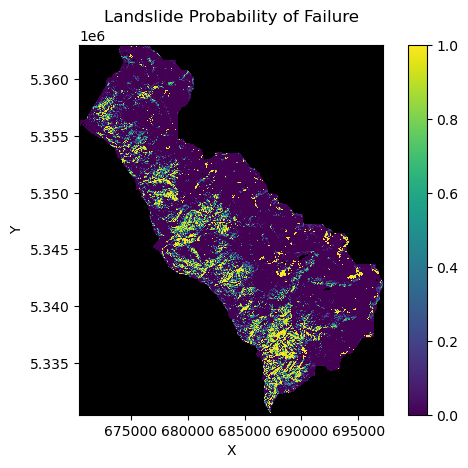

In [13]:
imshow_grid_at_node(grid, "landslide__probability_of_failure", cmap="viridis", limits=(0, 1))
plt.title("Landslide Probability of Failure")
plt.show()

In [15]:
import numpy as np
import rasterio
from pathlib import Path

out_dir = Path("/mnt/c/Users/amehedi/Downloads")
template_tif = SCENARIO_DIR / "topographic__elevation.tif"
nodata = -999999.0

export_fields = [
    ("surface_water__discharge", "node"),  # exported only if present
    ("topographic__slope", "node"),
    ("topographic__specific_contributing_area", "node"),
    ("soil__transmissivity", "node"),
    ("vegetation__live_leaf_area_index", "node"),
    ("vegetation__cover_fraction", "node"),
    ("soil_moisture__initial_saturation_fraction", "node"),
    ("surface__potential_evapotranspiration_rate", "cell"),
    ("soil_moisture__root_zone_leakage", "cell"),
    ("surface__runoff", "cell"),
    ("soil_moisture__saturation_fraction", "cell"),
    ("surface__evapotranspiration", "cell"),
    ("vegetation__water_stress", "cell"),
    ("groundwater__recharge_mean", "node"),
    ("groundwater__recharge_standard_deviation", "node"),
    ("groundwater__runoff_mean", "node"),
    ("test_runoff", "node"),
    ("test_recharge", "node"),
    ("routed_recharge_max", "node"),  # exported only if present
    ("landslide__probability_of_failure", "node"),
    ("soil__probability_of_saturation", "node"),
    ("soil__mean_relative_wetness", "node"),
]

def field_to_node_raster(grid, field, at, nodata=-999999.0):
    if at == "node":
        vals = grid.at_node[field].astype("float32")
        return np.flipud(vals.reshape(grid.shape))

    arr = np.full(grid.number_of_nodes, nodata, dtype="float32")
    arr[grid.node_at_cell] = grid.at_cell[field].astype("float32")
    return np.flipud(arr.reshape(grid.shape))

with rasterio.open(template_tif) as src:
    profile = src.profile.copy()
    transform = src.transform
    height = src.height
    width = src.width

profile.update(dtype="float32", count=1, nodata=nodata)

saved = []
for field, at in export_fields:
    if at == "node" and field not in grid.at_node:
        continue
    if at == "cell" and field not in grid.at_cell:
        continue

    raster = field_to_node_raster(grid, field, at, nodata=nodata)

    tif_path = out_dir / f"{field}.tif"
    asc_path = out_dir / f"{field}.asc"

    with rasterio.open(tif_path, "w", **profile) as dst:
        dst.write(raster, 1)

    with open(asc_path, "w") as f:
        f.write(f"ncols         {width}\n")
        f.write(f"nrows         {height}\n")
        f.write(f"xllcorner     {transform.c}\n")
        f.write(f"yllcorner     {transform.f + height * transform.e}\n")
        f.write(f"cellsize      {transform.a}\n")
        f.write(f"NODATA_value  {nodata}\n")
        np.savetxt(f, raster, fmt="%.6f")

    saved.append(field)

print("Exported:")
for name in saved:
    print(name)

/tmp/ipykernel_268624/1009985608.py:36: RuntimeWarning: overflow encountered in cast
  vals = grid.at_node[field].astype("float32")


Exported:
surface_water__discharge
topographic__slope
topographic__specific_contributing_area
soil__transmissivity
vegetation__live_leaf_area_index
vegetation__cover_fraction
soil_moisture__initial_saturation_fraction
surface__potential_evapotranspiration_rate
soil_moisture__root_zone_leakage
surface__runoff
soil_moisture__saturation_fraction
surface__evapotranspiration
vegetation__water_stress
groundwater__recharge_mean
groundwater__recharge_standard_deviation
groundwater__runoff_mean
test_runoff
test_recharge
landslide__probability_of_failure
soil__probability_of_saturation
soil__mean_relative_wetness
